<a href="https://colab.research.google.com/github/MiorLear/Learning-Log/blob/main/Actividad_de_Programaci%C3%B3n_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importando Librerias
from sklearn . datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score
from plotly.subplots import make_subplots
from google.colab import drive
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

print('ready')

ready


In [ ]:
#Importando Dataset AlfonsoWatts
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/KEY/ML/alfonsopower.csv'
df = pd.read_csv(path, encoding='utf-8')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
df.describe()

,X_001,X_002,X_003,X_004,X_005,X_006,X_007,X_008,X_009,X_010,...,X_162,X_163,X_164,X_165,X_166,X_167,X_168,X_169,X_170,alfonsopower
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.011192,-0.016075,0.015086,-0.013802,-0.013153,-0.029769,0.001909,0.004205,-0.008432,0.023624,...,-0.007637,0.006301,0.024040,0.001000,-0.004905,-0.006032,0.000375,0.013975,0.003642,1.504331
std,1.008275,0.995707,1.014777,1.009512,0.998965,1.000593,0.996835,0.998417,1.000146,0.993984,...,1.003554,1.001405,0.994620,0.994236,1.001615,1.006313,0.993461,1.004869,0.996415,12.256775
min,-3.900567,-3.430316,-3.571353,-3.716072,-3.759122,-3.762649,-3.235766,-3.680505,-4.231575,-4.172471,...,-3.587332,-3.722445,-5.153296,-3.881972,-3.583620,-4.083107,-4.194051,-3.694958,-3.316407,-42.285922
25%,-0.660922,-0.699724,-0.659552,-0.703316,-0.685976,-0.704131,-0.678979,-0.664382,-0.684506,-0.654600,...,-0.671769,-0.665530,-0.640036,-0.671440,-0.690034,-0.700101,-0.667632,-0.663840,-0.668040,-6.702028
50%,0.011123,-0.017881,0.022218,-0.014755,-0.017210,-0.036043,0.009962,0.007103,0.001915,0.021835,...,-0.015097,0.004501,0.024354,-0.017090,-0.005509,0.002046,-0.013782,0.012269,0.013838,1.667394
75%,0.687926,0.668446,0.715309,0.657051,0.654017,0.662879,0.686472,0.678742,0.663206,0.703727,...,0.666038,0.689282,0.687959,0.663801,0.676787,0.688958,0.667928,0.685388,0.674181,9.730119
max,3.565135,3.359250,3.599475,3.652672,3.703032,3.580290,3.534587,4.061026,4.214847,3.510093,...,3.651061,3.670860,4.045916,3.627701,3.758954,3.597030,4.057738,3.866643,3.765528,51.119758


In [ ]:
df.head()

,X_001,X_002,X_003,X_004,X_005,X_006,X_007,X_008,X_009,X_010,...,X_162,X_163,X_164,X_165,X_166,X_167,X_168,X_169,X_170,alfonsopower
0,0.732962,0.045724,0.824186,-0.728014,2.933181,0.064128,0.400347,1.442459,-0.526989,-1.752355,...,1.767058,0.071714,0.240985,0.768822,0.125092,2.714083,0.325474,0.622918,-0.947266,12.674213
1,1.379110,-0.953897,2.026166,0.355270,0.642463,-0.635347,1.069440,-0.850588,0.817684,-0.660818,...,0.644667,-0.693005,0.195136,1.170382,0.540959,-1.557459,-0.213147,-1.208744,0.650604,7.213715
2,1.302927,-1.409670,0.383523,-0.881926,-1.072689,-0.539818,-1.061546,-0.103982,-0.145041,-0.512753,...,-1.860943,1.802557,-1.733961,-0.300498,0.896027,-0.457872,-0.911116,0.735138,-1.653646,18.358821
3,-0.133366,0.790866,-0.636214,0.466466,0.539612,1.170099,-1.285977,-0.387690,-0.494620,0.276379,...,-1.094927,0.141713,-1.200556,0.136278,-0.262332,0.420850,0.300325,0.235878,-2.197905,-8.265633
4,-1.341085,0.883501,-0.451850,-0.215526,-0.643430,0.119950,-1.126953,-0.746415,1.959076,0.355519,...,-0.210028,1.105673,0.923749,-0.233370,-0.162167,0.070429,-0.315403,1.688087,0.860836,2.538194


### Asignando Variables
AlfonsoPower es mi variante dependiente, las demas son mis variables independientes

In [ ]:
x = df.drop(columns=['alfonsopower']).values
y = df['alfonsopower'].values


### Definiendo función de normalización

In [ ]:
def normalizar(x):
  scaler = StandardScaler()
  x_normalizado = scaler.fit_transform(x)
  return x_normalizado

In [ ]:
x_n = normalizar(x)

### Definiendo Función Closed Form


In [ ]:
def closed_form(x, y):
  model_cf = LinearRegression()
  model_cf.fit(x, y)
  score_cf = model_cf.score(x, y)   # R²
  return model_cf, score_cf


### Definiendo Función SGD

In [ ]:
def sgd(x, y):
  model_sgd = SGDRegressor(
    max_iter=1000,
    tol=1e-4,
    learning_rate='adaptive',   # ajusta alpha automáticamente
    eta0=0.01,
    random_state=42
  )
  model_sgd.fit(x, y)
  score_sgd = model_sgd.score(x, y)
  return model_sgd, score_sgd

###Comparando Resultados:


In [ ]:
model_cf, score_cf = closed_form(x_n, y)
model_sgd, score_sgd = sgd(x_n, y)

print(f"{'Modelo':<25} {'R^2 Score':>10}")
print("─" * 38)
print(f"{'Closed Form (10K)':<25} {score_cf:>10.6f}")
print(f"{'SGD (10K)':<25} {score_sgd:>10.6f}")

Modelo                     R^2 Score
──────────────────────────────────────
Closed Form (10K)           0.991990
SGD (10K)                   0.991990


### Benchmark Resultados

In [ ]:
sizes   = [1000, 2000, 3000, 5000, 7500, 10000]
REPS    = 3
results = []

for size in sizes:
    x_sub = x_n[:size]
    y_sub = y[:size]

    # — Closed Form —
    times_cf = []
    for _ in range(REPS):
        start = time.time()
        m_cf, s_cf = closed_form(x_sub, y_sub)
        times_cf.append(time.time() - start)

    # — SGD —
    times_sgd = []
    for _ in range(REPS):
        start = time.time()
        m_sgd, s_sgd = sgd(x_sub, y_sub)
        times_sgd.append(time.time() - start)

    results.append({
        'size':      size,
        'time_cf':   np.mean(times_cf),
        'time_sgd':  np.mean(times_sgd),
        'score_cf':  s_cf,
        'score_sgd': s_sgd
    })
    print(f"n={size:<6} | CF: {np.mean(times_cf):.4f}s  R^2={s_cf:.4f} | SGD: {np.mean(times_sgd):.4f}s  R^2={s_sgd:.4f}")

results_df = pd.DataFrame(results)

n=1000   | CF: 0.0221s  R^2=0.9933 | SGD: 0.0518s  R^2=0.9933
n=2000   | CF: 0.0297s  R^2=0.9926 | SGD: 0.1010s  R^2=0.9926
n=3000   | CF: 0.0669s  R^2=0.9923 | SGD: 0.1773s  R^2=0.9923
n=5000   | CF: 0.1468s  R^2=0.9921 | SGD: 0.3259s  R^2=0.9921
n=7500   | CF: 0.1483s  R^2=0.9921 | SGD: 0.4277s  R^2=0.9921
n=10000  | CF: 0.5109s  R^2=0.9920 | SGD: 0.8343s  R^2=0.9920


### Gráfica: Processing Time × Dataset Size



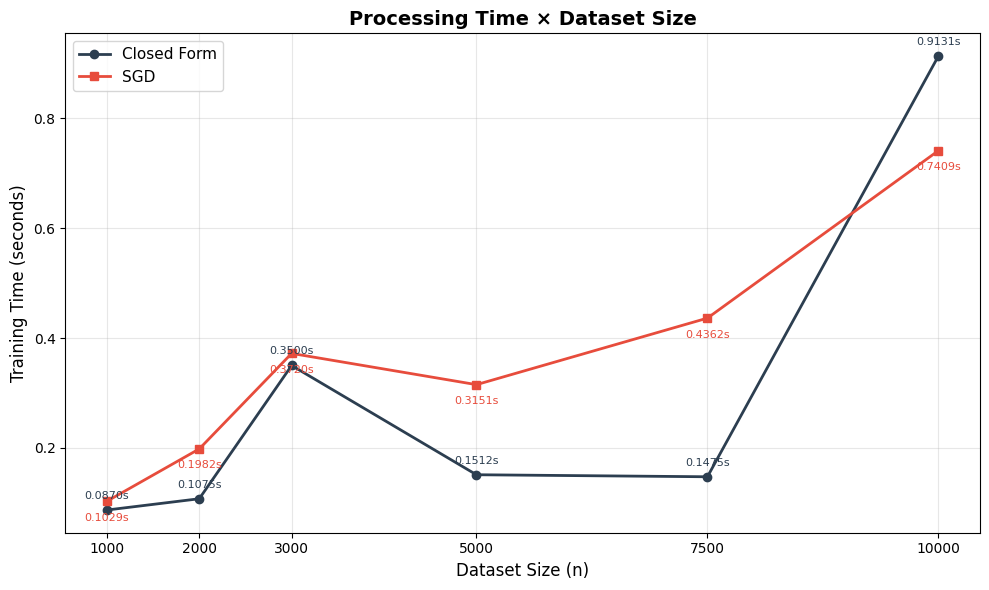

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results_df['size'], results_df['time_cf'],
        marker='o', linewidth=2, color='#2c3e50', label='Closed Form')
ax.plot(results_df['size'], results_df['time_sgd'],
        marker='s', linewidth=2, color='#e74c3c', label='SGD')

ax.set_title('Processing Time × Dataset Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset Size (n)', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_xticks(results_df['size'])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

for _, row in results_df.iterrows():
    ax.annotate(f"{row['time_cf']:.4f}s",
                xy=(row['size'], row['time_cf']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#2c3e50')
    ax.annotate(f"{row['time_sgd']:.4f}s",
                xy=(row['size'], row['time_sgd']),
                xytext=(0, -14), textcoords='offset points',
                ha='center', fontsize=8, color='#e74c3c')

plt.tight_layout()
plt.savefig('processing_time_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfica: Score × Dataset Size

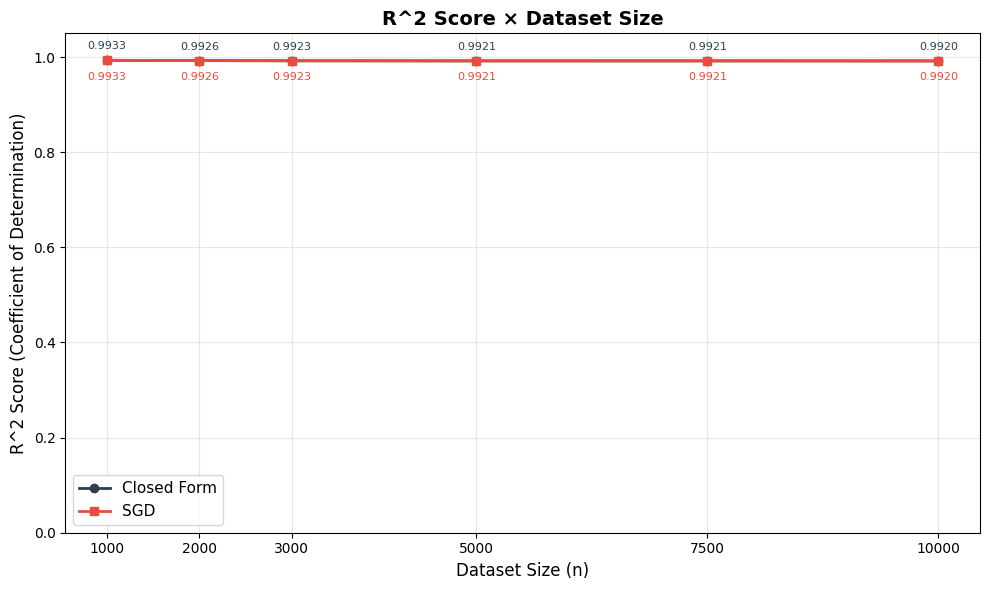

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results_df['size'], results_df['score_cf'],
        marker='o', linewidth=2, color='#2c3e50', label='Closed Form')
ax.plot(results_df['size'], results_df['score_sgd'],
        marker='s', linewidth=2, color='#e74c3c', label='SGD')

ax.set_title('R^2 Score × Dataset Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset Size (n)', fontsize=12)
ax.set_ylabel('R^2 Score (Coefficient of Determination)', fontsize=12)
ax.set_xticks(results_df['size'])
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

for _, row in results_df.iterrows():
    ax.annotate(f"{row['score_cf']:.4f}",
                xy=(row['size'], row['score_cf']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#2c3e50')
    ax.annotate(f"{row['score_sgd']:.4f}",
                xy=(row['size'], row['score_sgd']),
                xytext=(0, -14), textcoords='offset points',
                ha='center', fontsize=8, color='#e74c3c')

plt.tight_layout()
plt.savefig('score_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones
- Scikit Learn es una libreria muy util, ya que trae muchos pasos build-in y simplifica mucho el proceso de encontrar descenso por gradiente.
- La Closed form, demostró ser más lenta debido a que la cantidad de dimensiones era mayor y esto aumento su complejidad O(d^3), en cambio descendo por gradiente tiene una complejidad de O($n*d*t$)
- Aprendimos como interpretar las mediciones del tiempo en los benchmarks.
- Descubrimos que las R^2 dan lo mismo en ambos métodos debido a que llegaron al mismo resultado, y eso nos indica que ambos métodos probaron ser igual de eficientes.